## Linear regression and gradient descent model

This is a simple program where we:

* Generate fake data and plot scatter
* Define hypothesis function
* Define the cost function by the least squares method
* Implement gradient descent 
* Plot learned line and compare against data
* Print learned theta and check if close to the truth
* Compare learning rates and number of iterations

In [2]:
import numpy as np
import matplotlib.pyplot as plt

First we define our training data, which is going to have fake error/noise added to it in a Normal Distribution, to simulate real data. We also define the design matrix X that stacks our input data.

(100, 1)


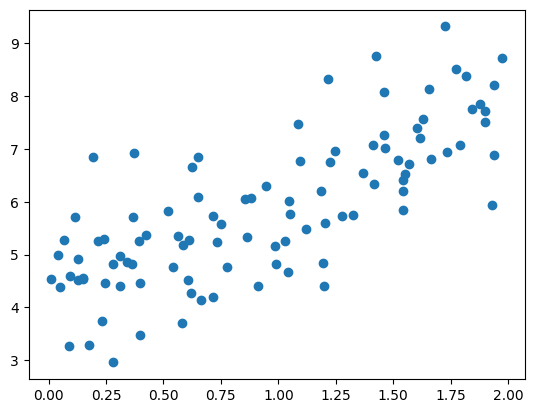

In [10]:
np.random.seed(42) #keep the same random data every time we run the code

m = 100 #training examples
n = 1 #features

x = np.array(2 * np.random.rand(m, 1)) #random input values
X = np.hstack((np.ones((m,1)), x)) #design matrix X
y = np.array(2 * x + 4 + np.random.randn(m, 1)) #outputs with normally distributed noise
print(y.shape)
plt.scatter(X[:,1],y)
plt.show()


Now, we define the functions that will be used to train the model using gradient descent. We need the function that calculates the hypothesis, and the cost function to keep track of the errors through each iteration. 

In [3]:
def predict(X, theta):
    # h(theta)
    return X @ theta 


def cost_function(X, y, theta):
    # J(theta)
    m = len(y)
    errors = predict(X, theta) - y
    return 0.5 * np.sum(errors ** 2) / m

Now we train the model using Batch Gradient Descent. We do that in 2 different ways: manually, and vectorized.

In [27]:
def gradient_descent_manually(X, y, theta, alpha, iterations):
    cost_history = [] #array to keep track of cost
    m = len(y)
    n = len(theta)

    for _ in range(iterations):
        # Batch gradient descent assumes all updates are perfomed simultaneously, all using the older theta value
        # We copy the value to ensure we use the original value for the full step in the descent
        new_theta = theta.copy() 
        errors = predict(X, theta) - y
        cost_history.append(cost_function(X, y, theta))

        for j in range(n):
            summation = 0

            for i in range(m):
                summation += errors[i] * X[i, j]

            new_theta[j] = theta[j] - alpha * summation / m

        theta = new_theta

    return theta, cost_history

def gradient_descent_vectorized(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        cost_history.append(cost_function(X, y, theta))
        errors = predict(X, theta) - y
        theta = theta - (alpha / m) * X.T @ errors
        
    return theta, cost_history

Finally, we can create some plots. For instance, we can plot the result from the model and see if we recover the parameters (intercept 4, slope 2). We do the same with the manual and the vectorized gradient descent models to ensure they match.

Parameter values from manual model 
 Intercept:  [4.21509616] 
 Slope:  [1.77011339]
Parameter values from vectorized model 
 Intercept:  [4.21509616] 
 Slope:  [1.77011339]


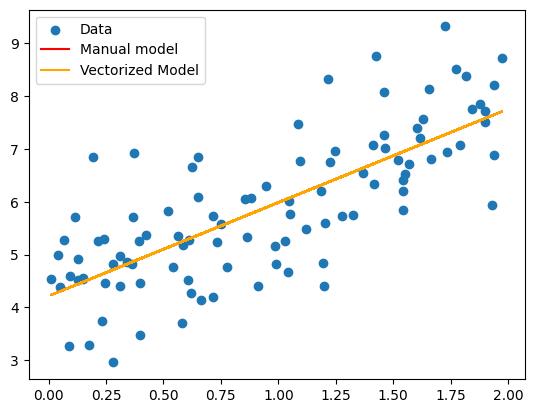

In [57]:
theta0 = np.zeros((n+1, 1)) #initial parameter value
alpha = 0.8 #learning rate
iterations = 1000

theta_manual, cost_history_manual = gradient_descent_manually(X, y, theta0, alpha, iterations)

print('Parameter values from manual model \n Intercept: ', theta_manual[0], '\n Slope: ', theta_manual[1])
y_pred_manual = predict(X, theta_manual)

plt.scatter(X[:,1], y, label = "Data")
plt.plot(X[:,1], y_pred_manual, label = "Manual model", color = 'red')


theta_vectorized, cost_history_vectorized = gradient_descent_vectorized(X, y, theta0, alpha, iterations)
print('Parameter values from vectorized model \n Intercept: ', theta_vectorized[0], '\n Slope: ', theta_vectorized[1])
y_pred_vec = predict(X, theta_vectorized)

plt.plot(X[:,1], y_pred_vec, label = "Vectorized Model", color = 'orange')

plt.legend()
plt.show()

The above plot confirms that the implementation of the gradient descent in the vectorized form is correct. From now on, we use the vectorized form only, since we are certain it works properly. We now plot the cost function over each iteration to visualize the process of minimizing the square difference.

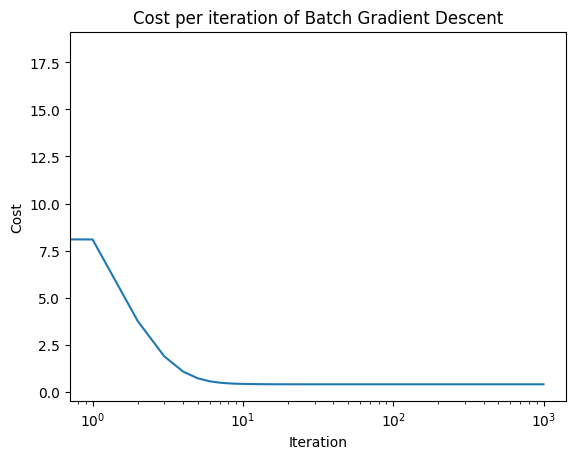

In [58]:
plt.plot(cost_history_vectorized)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.xscale('log')
plt.title('Cost per iteration of Batch Gradient Descent')
plt.show()

## Comparing learning rates
In the previous code, the learning rate was constantly changed in an attempt to get to the optimal rate (the largest rate possible without overshooting). We now compare different learning rates in a more sistematic way, by plotting different model results with different rates.

Parameter values model for alpha = 0.01 
 Intercept:  [3.9424452] 
 Slope:  [2.01084936]
Parameter values model for alpha = 0.02 
 Intercept:  [4.16535954] 
 Slope:  [1.81402812]
Parameter values model for alpha = 0.2 
 Intercept:  [4.21509616] 
 Slope:  [1.77011339]
Parameter values model for alpha = 0.4 
 Intercept:  [4.21509616] 
 Slope:  [1.77011339]
Parameter values model for alpha = 0.8 
 Intercept:  [4.21509616] 
 Slope:  [1.77011339]
Parameter values model for alpha = 0.9 
 Intercept:  [4.21509616] 
 Slope:  [1.77011339]


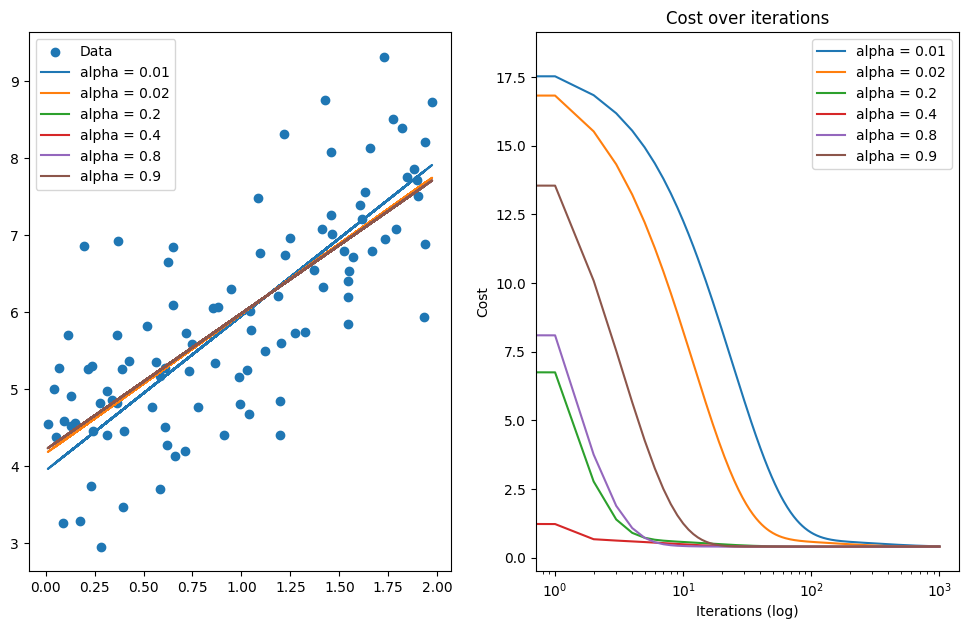

In [61]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7))

learning_rates = np.array([0.01, 0.02, 0.2, 0.4, 0.8, 0.9])

ax1.scatter(X[:, 1], y, label = 'Data')

for rate in learning_rates:
    theta, cost_history = gradient_descent_vectorized(X, y, theta0, rate, iterations)
    print(f'Parameter values model for alpha = {rate} \n Intercept: ', theta[0], '\n Slope: ', theta[1])
    y_pred = predict(X, theta)
    ax1.plot(X[:,1], y_pred, label = f'alpha = {rate}')
    ax2.plot(cost_history, label = f'alpha = {rate}')

ax1.legend()
ax2.legend()
ax2.set_xscale('log')
ax2.set_title('Cost over iterations')
ax2.set_xlabel('Iterations (log)')
ax2.set_ylabel('Cost')
plt.show() 

These plots show the different behaviors of the model under different learning rates. For 1000 iterations, low learning rates (0.01 and 0.02) didn't yet converge. In the left plot, we can see that the blue (0.01) and yellow (0.02) lines are separate from the other ones. The higher learning rates arrive at convergence with fewer iterations, the best model being the one with 0.8 learning rate (purple line), which converges at around 10 iterations. As we approach 1, the model diverges, this is why the 0.9 learning rate (brown line) takes more iterations than the 0.8 learning rate to converge. The model with 0.9 learning rate overshoots in the first iteration, then bounces back and forth before converging.